In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import traceback
from dotenv import load_dotenv
from mlflow.tracking import MlflowClient
import pandas as pd

f:\DiskE\SKRIPSI-CODE\skripsi-code\ai\.venv\Lib\site-packages\mlflow\utils\autologging_utils\versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


### Try to load using MLflow API

This doesn't work, scroll below to the next chapter

In [2]:
# load_dotenv()

# tracking_uri = os.getenv("MLFLOW_TRACKING_URI")
# mlflow.set_tracking_uri(tracking_uri)  # type: ignore
# client: MlflowClient = MlflowClient(tracking_uri=tracking_uri)

# # RUN_ID = "906cef2b2f4f465eb47f298a50065e54"
# RUN_ID = "15fc890603d149e4918a1c6cfbf9aa48"

# METRICS_TO_PLOT: list[str] = [
#     # "avg_train_loss",
#     "val_loss_avg",
#     # "val_macro_pr_auc",
#     # "val_macro_roc_auc",
# ]

# run = client.get_run(RUN_ID)
# print(list(run.data.metrics.keys()))
# # print(run)


# def get_and_clean_metric(client: MlflowClient, run_id, metric_key):
#     """Fetches metric history from MLflow and removes NaN or None values."""
#     try:
#         history = client.get_metric_history(run_id, metric_key)
#         print("history", history)

#         steps = []
#         values = []

#         for m in history:
#             if m.value is not None and not np.isnan(m.value):
#                 steps.append(m.step)
#                 values.append(m.value)

#         return steps, values

#     except Exception as e:
#         traceback.print_exc()
#         print(f"Could not retrieve '{metric_key}': {e}")
#         return [], []


# num_metrics = len(METRICS_TO_PLOT)
# fig, axes = plt.subplots(nrows=num_metrics, ncols=1, figsize=(10, 4 * num_metrics))

# # Check axes is iterable even if there's only one metric
# if num_metrics == 1:
#     axes = [axes]

# for ax, metric_key in zip(axes, METRICS_TO_PLOT):
#     steps, values = get_and_clean_metric(client, RUN_ID, metric_key)

#     if len(steps) == 0:
#         ax.text(
#             0.5,
#             0.5,
#             f"No valid data for {metric_key}",
#             ha="center",
#             va="center",
#             transform=ax.transAxes,
#         )
#         ax.set_title(metric_key)
#         continue

#     ax.plot(steps, values, marker="o", linestyle="-", color="b", label=metric_key)
#     ax.set_title(f"{metric_key} over Epochs")
#     ax.set_xlabel("Epoch / Step")
#     ax.set_ylabel("Value")
#     ax.grid(True, linestyle="--", alpha=1)
#     ax.legend()

# plt.tight_layout()
# plt.show()

# This works

In [3]:
df = pd.read_csv("./mlflow_pgdump/906cef_history.csv")
df.head()

,key,value,timestamp,run_uuid,step,is_nan
0,val_pr_auc_mood/theme---slow,0.045309,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
1,val_roc_auc_mood/theme---slow,0.742095,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
2,val_roc_auc_mood/theme---movie,0.767623,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
3,val_pr_auc_mood/theme---movie,0.108775,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
4,val_roc_auc_mood/theme---motivational,0.865343,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f


In [4]:
def plot_db_metrics(df: pd.DataFrame, metrics_to_plot: list[str]):
    """
    Takes a raw MLflow PostgreSQL metrics dump and a list of metric keys,
    filters out the NaNs, and plots them in stacked subplots.
    """
    num_metrics = len(metrics_to_plot)

    if num_metrics == 0:
        print("No metrics provided to plot.")
        return

    _, axes = plt.subplots(nrows=num_metrics, ncols=1, figsize=(10, 4 * num_metrics))

    if num_metrics == 1:
        axes = [axes]

    for ax, metric_key in zip(axes, metrics_to_plot):
        if "pr" in metric_key:
            df_clean = df[
                (df["key"] == metric_key)
                & (df["is_nan"].isin(["f", "F", False, 0]))
                & (df["value"] > 0.0)
            ].copy()
        elif "roc" in metric_key:
            df_clean = df[
                (df["key"] == metric_key)
                & (df["is_nan"].isin(["f", "F", False, 0]))
                & (df["value"] > 0.5)
            ].copy()
        else:
            df_clean = df[
                (df["key"] == metric_key)
                & (df["is_nan"].isin(["f", "F", False, 0]))
                & (df["value"].notna())
            ].copy()

        df_clean = df_clean.sort_values(by="step")

        # Handle edge case where the metric exists but all values were NaN
        if df_clean.empty:
            ax.text(
                0.5,
                0.5,
                f"No valid data found for '{metric_key}'",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(metric_key)
            continue

        ax.plot(
            df_clean["step"].apply(lambda x: x + 1),
            df_clean["value"],
            marker="o",
            linestyle="-",
            color="b",
            label=metric_key,
        )

        ax.set_title(f"{metric_key} over epochs")
        ax.set_xlabel("epoch")
        ax.set_xticks(np.arange(1, stop=len(df_clean["step"]) + 1))
        ax.set_ylabel("value")
        ax.grid(True, linestyle="--", alpha=0.7)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [5]:
METRICS_TO_PLOT = [
    "train_loss",
    "avg_train_loss",
    "val_loss_avg",
    "val_macro_pr_auc",
    "val_macro_roc_auc"
]

# plot_db_metrics(df, METRICS_TO_PLOT)

# Testing results

In [6]:
def results_to_gsheets_manually(csv_file):
    adf = pd.read_csv(csv_file)
    print(adf.head())

    print(adf[(adf["step"] == 0) & (adf["key"] == "test_macro_pr_auc")])
    print(adf[(adf["step"] == 0) & (adf["key"] == "test_macro_roc_auc")])
    # print(adf[(adf["step"] == 24) & (adf["key"] == "test_macro_pr_auc")])
    # print(adf[(adf["step"] == 24) & (adf["key"] == "test_macro_roc_auc")])

    # print(adf[adf["step"] == 24])

    exclusion = [
        "test_macro_pr_auc",
        "test_macro_roc_auc",
        "test_loss_avg",
        "test_loss_std",
    ]

    prauc_keys = []
    prauc_vals = []
    rocauc_keys = []
    rocauc_vals = []
    optimal_keys = []
    optimal_vals = []

    for item in adf.iterrows():
        # print(item[1]["key"])
        if item[1]["key"] not in exclusion:
            clean_key = "_".join(item[1]["key"].split("_")[1:]).replace(
                "mood/theme---", ""
            )
            optimal_key = "_".join(item[1]["key"].split("_")).replace(
                "mood/theme---", ""
            )
            if "pr" in clean_key and "precision" not in clean_key:
                prauc_keys.append(clean_key)
                prauc_vals.append(item[1]["value"])
            elif "roc" in clean_key:
                rocauc_keys.append(clean_key)
                rocauc_vals.append(item[1]["value"])
            elif "optimal" in optimal_key:
                optimal_keys.append(optimal_key)
                optimal_vals.append(item[1]["value"])

            # print(f"{clean_key} {item[1]["value"]}")

    print(len(prauc_keys))
    print(len(prauc_vals))
    print(len(rocauc_keys))
    print(len(rocauc_vals))
    print(len(optimal_keys))
    print(len(optimal_vals))

    return (
        prauc_keys,
        prauc_vals,
        rocauc_keys,
        rocauc_vals,
        optimal_keys,
        optimal_vals,
    )

In [7]:
pk, pv, rk, rv, ok, ov = results_to_gsheets_manually(
    csv_file="./mlflow_pgdump/f2_attn_history.csv"
)

                                  key     value      timestamp  \
0                       test_loss_avg  0.053680  1781567719258   
1                       test_loss_std  0.029127  1781567719258   
2     test_pr_auc_mood_theme---action  0.037239  1781567719258   
3    test_roc_auc_mood_theme---action  0.742968  1781567719258   
4  test_precision_mood_theme---action  0.050000  1781567719258   

                           run_uuid  step is_nan  
0  b53039e390944fd8ba0560284620376f     0      f  
1  b53039e390944fd8ba0560284620376f     0      f  
2  b53039e390944fd8ba0560284620376f     0      f  
3  b53039e390944fd8ba0560284620376f     0      f  
4  b53039e390944fd8ba0560284620376f     0      f  
                   key    value      timestamp  \
282  test_macro_pr_auc  0.12185  1781567719258   

                             run_uuid  step is_nan  
282  b53039e390944fd8ba0560284620376f     0      f  
                    key     value      timestamp  \
283  test_macro_roc_auc  0.746132  178

In [8]:
# for i, item in enumerate(prauc_keys):
    # print(f"{str(item).replace("pr_auc_", "")} {prauc_vals[i]}")
    # print(f"{str(item).replace("pr_auc_", "")}")

In [9]:
for item in pv:
    print(item)

0.0372386556340375
0.0940246031905226
0.2238872672873129
0.0193874283025014
0.0697372420896933
0.0323997280312193
0.2589330276776988
0.2035022027071469
0.1321903628018066
0.0210722428019797
0.2206685393065242
0.2645855740785741
0.7372198012120393
0.0549810397647241
0.0352674962367974
0.0437924449172089
0.0644980501568391
0.1686063981642984
0.1554761104143147
0.4047962574989696
0.061327006931144
0.3144086265276658
0.1235371276629308
0.0477186253397388
0.0363058850513241
0.0299892699073926
0.2638448218533853
0.1382113982948402
0.0207492292012685
0.0152781383145216
0.0839144220282211
0.157446195552089
0.1609633850270146
0.0345485620618193
0.0893727994919672
0.2551143449484225
0.0236059559376195
0.0206371258798686
0.0817125737016087
0.0978678605610264
0.1028786214286879
0.147468062847316
0.0255596554059244
0.0978765162068812
0.0960365647551028
0.0183412177400439
0.0361651215487505
0.0619647652457463
0.0415828619474549
0.0319662026834223
0.0424315392405094
0.502766997754286
0.18208273670721

In [10]:
for item in rv:
    print(item)

0.7429683490162532
0.6768016009148085
0.7962475342490544
0.5997642451850076
0.7610141627261215
0.6523494263191854
0.820441944663398
0.7689693745310688
0.803068567589231
0.6879246165737765
0.8619449639878893
0.795655637794813
0.9426755907701854
0.6749383321081435
0.6824036888293916
0.6933793035349878
0.5695499382848282
0.6574120380894648
0.7516298370729826
0.8476882129454494
0.8480261136712749
0.7631150302493955
0.8586995196584238
0.7992348320693391
0.6877041725781221
0.7846286760108674
0.7673403332031243
0.922948169281978
0.706348148641745
0.5633148974922814
0.5910707918483776
0.7419367796783476
0.8059133123961545
0.6228517563479739
0.6500546721298147
0.764995711000363
0.5273273671245264
0.6497869013693793
0.8629310344827585
0.7608551634447084
0.8164836412133595
0.727989484263527
0.8258189325364171
0.772082963062323
0.7003866177874989
0.6987652062562884
0.6807423542879464
0.7308743324300114
0.8573011209768748
0.786750936329588
0.8181681086128395
0.8726932656338652
0.9205141970890004
0.

In [11]:
for item in ov:
    print(item)

0.9384917616844176
0.7919057011604309
0.7124878764152527
0.8194613456726074
0.914301872253418
0.8486461043357849
0.7108395099639893
0.7730967998504639
0.7341631650924683
0.8408967852592468
0.7208936810493469
0.6864554286003113
0.8396633267402649
0.7320618033409119
0.8012367486953735
0.7554842829704285
0.7485377192497253
0.7658880949020386
0.7667146921157837
0.8556296229362488
0.8758651614189148
0.8051517009735107
0.574310302734375
0.5862431526184082
0.8697110414505005
0.838223397731781
0.588200032711029
0.8901641964912415
0.6873646974563599
0.852715790271759
0.7091341614723206
0.7456263303756714
0.8924466371536255
0.8743495941162109
0.6470102667808533
0.7488417625427246
0.7806753516197205
0.7079427242279053
0.7686773538589478
0.6313688158988953
0.7381137013435364
0.8426156044006348
0.3765849173069
0.7575901746749878
0.7502564787864685
0.9525056481361388
0.7383204698562622
0.7187602519989014
0.8844442367553711
0.810964822769165
0.8348584175109863
0.8233618140220642
0.7748796343803406
0.

# PR/ROC curves

In [12]:
import os
import glob
import math
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.artifacts
from dotenv import load_dotenv

# Folder to save the output plots locally
OUTPUT_PLOTS_DIR = "./plots"

def load_environment():
    load_dotenv()
    mlflow_uri = os.environ.get("MLFLOW_TRACKING_URI")
    if not mlflow_uri:
        raise ValueError("MLFLOW_TRACKING_URI not found in environment variables.")
    mlflow.set_tracking_uri(mlflow_uri)
    print(f"Tracking URI set to: {mlflow_uri}")

def extract_label_from_filename(filepath, prefix):
    """
    Extracts the 'safe_label' from a filename like 'pr_curve_Acoustic_Guitar.csv'.
    """
    filename = os.path.basename(filepath)
    label = filename.replace(prefix, "").replace(".csv", "")
    return label

def plot_grid(files, prefix, x_col, y_col, plot_title, output_filename, is_roc=False):
    """
    Plots a grid of curves. Defaults to 4 columns and calculates rows dynamically.
    """
    if not files:
        print(f"No files found for {plot_title}. Skipping.")
        return

    # Sort files alphabetically by the label name
    files = sorted(files, key=lambda f: extract_label_from_filename(f, prefix))
    
    num_plots = len(files)
    cols = 4
    rows = math.ceil(num_plots / cols)

    # Make the figure very large so 56 subplots are readable
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(6 * cols, 4 * rows))
    fig.suptitle(plot_title, fontsize=24, y=0.99)
    
    axes = axes.flatten()

    for i, filepath in enumerate(files):
        ax = axes[i]
        label_name = extract_label_from_filename(filepath, prefix)
        
        try:
            df = pd.read_csv(filepath)
            
            # Plot the actual curve
            ax.plot(df[x_col], df[y_col], color='b', lw=2)
            
            # If ROC, add the diagonal chance line
            if is_roc:
                ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
                
            ax.set_title(label_name, fontsize=14, weight='bold')
            ax.set_xlim([-0.05, 1.05])
            ax.set_ylim([-0.05, 1.05])
            ax.set_xlabel(x_col.upper())
            ax.set_ylabel(y_col.capitalize())
            ax.grid(True, linestyle='--', alpha=0.6)
            
        except Exception as e:
            ax.set_title(f"{label_name} (Error)", fontsize=14)
            ax.text(0.5, 0.5, str(e), ha='center', va='center', fontsize=8)

    # Hide any unused subplots if the number of files isn't a perfect multiple of 4
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=3.0)
    
    out_path = os.path.join(OUTPUT_PLOTS_DIR, output_filename)
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f"Saved grid plot to: {out_path}")
    plt.close(fig)

def plot_macro(filepath, x_col, y_col, plot_title, output_filename, is_roc=False):
    """
    Plots a single macro-average curve.
    """
    if not os.path.exists(filepath):
        print(f"Macro file not found: {filepath}. Skipping.")
        return
        
    try:
        df = pd.read_csv(filepath)
        
        plt.figure(figsize=(8, 6))
        plt.plot(df[x_col], df[y_col], color='purple', lw=3, label="Macro Average")
        
        if is_roc:
            plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Chance")
            
        plt.title(plot_title, fontsize=16, weight='bold')
        plt.xlim([-0.05, 1.05])
        plt.ylim([-0.05, 1.05])
        plt.xlabel(x_col.upper(), fontsize=12)
        plt.ylabel(y_col.capitalize(), fontsize=12)
        plt.legend(loc="lower right")
        plt.grid(True, linestyle='--', alpha=0.6)
        
        out_path = os.path.join(OUTPUT_PLOTS_DIR, output_filename)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f"Saved macro plot to: {out_path}")
        plt.close()
        
    except Exception as e:
        print(f"Error plotting {filepath}: {e}")

def plot_all_curves(target_run_id: str):
    load_environment()
    
    if target_run_id == "YOUR_TESTING_RUN_ID_HERE":
        print("Please replace 'target_run_id' in the script with an actual MLflow run ID.")
        return

    os.makedirs(OUTPUT_PLOTS_DIR, exist_ok=True)

    print(f"Downloading artifacts for run {target_run_id}...")
    try:
        local_artifact_dir = mlflow.artifacts.download_artifacts(
            run_id=target_run_id,
            artifact_path="calculated_metrics"
        )
        print(f"Artifacts downloaded to: {local_artifact_dir}")
    except Exception as e:
        print(f"Failed to download artifacts. Are you sure the run ID is correct and artifacts exist? Error: {e}")
        return

    # 1. Gather files
    pr_files = glob.glob(os.path.join(local_artifact_dir, "pr_curve_*.csv"))
    roc_files = glob.glob(os.path.join(local_artifact_dir, "roc_curve_*.csv"))

    # Separate individual label files from the macro average file
    pr_label_files = [f for f in pr_files if "macro_average" not in f]
    roc_label_files = [f for f in roc_files if "macro_average" not in f]
    
    pr_macro_file = os.path.join(local_artifact_dir, "pr_curve_macro_average.csv")
    roc_macro_file = os.path.join(local_artifact_dir, "roc_curve_macro_average.csv")

    print(f"Found {len(pr_label_files)} PR files and {len(roc_label_files)} ROC files for individual labels.")

    # 2. Plot Per-Label Grid: PR-AUC (14x4)
    plot_grid(
        files=pr_label_files,
        prefix="pr_curve_",
        x_col="recall",
        y_col="precision",
        plot_title="Precision-Recall Curves by Label",
        output_filename=f"grid_pr_curves_{target_run_id}.png",
        is_roc=False
    )

    # 3. Plot Per-Label Grid: ROC-AUC (14x4)
    plot_grid(
        files=roc_label_files,
        prefix="roc_curve_",
        x_col="fpr",
        y_col="tpr",
        plot_title="ROC Curves by Label",
        output_filename=f"grid_roc_curves_{target_run_id}.png",
        is_roc=True
    )

    # 4. Plot Macro-Averages
    plot_macro(
        filepath=pr_macro_file,
        x_col="recall",
        y_col="precision",
        plot_title="Macro-Averaged Precision-Recall Curve",
        output_filename=f"macro_pr_curve_{target_run_id}.png",
        is_roc=False
    )
    
    plot_macro(
        filepath=roc_macro_file,
        x_col="fpr",
        y_col="tpr",
        plot_title="Macro-Averaged ROC Curve",
        output_filename=f"macro_roc_curve_{target_run_id}.png",
        is_roc=True
    )
    
    print("\nPlotting complete! Check the './plots' directory for the output images.")

In [13]:
# plot_all_curves("9f3cb99c242f4307a6f8872c2f73f11b") # CNN
# plot_all_curves("5192ad9a81b4484ea3ec447986ac3f9f") # GRU
# plot_all_curves("a9889184136f49978b22e36ed09fb0ba") # ATTN
# plot_all_curves("d686499c115d46afb69c591f3ba6863b") # GRU tahap 2
# plot_all_curves("141e8ff27e3b4f4b9dee325e9bd66d7f") # CNN
# plot_all_curves("24ae7423868848e4b13dd2369074eac0") # GRU
# plot_all_curves("b53039e390944fd8ba0560284620376f") # ATTN

# Correlations

In [14]:
# Compare CNN, GRU, and ATTN results based on the number of files and chunks for each label
def calculate_correlations(dataset_file, results_file):
    df1 = pd.read_csv(results_file)
    df2 = pd.read_csv(dataset_file)

    df2["DURATION"] = pd.to_numeric(df2["DURATION"], errors="coerce").fillna(0)
    df2["TAGS"] = df2["TAGS"].fillna("")

    records = []
    for _, row in df2.iterrows():
        tags_raw = row["TAGS"]
        if not tags_raw:
            continue
        tags = tags_raw.split("+")
        for t in tags:
            label = t.split("---")[-1].strip()
            records.append({"label": label, "duration": row["DURATION"]})

    df_exploded = pd.DataFrame(records)

    stats_df = df_exploded.groupby("label").agg(
        files_count=("label", "count"), dur_sum=("duration", "sum")
    )
    stats_df["chunks_count"] = (stats_df["dur_sum"] // 15).astype(int)

    df1["value"] = pd.to_numeric(df1["value"], errors="coerce")

    pr_mask = df1["key"].str.startswith("test_pr_auc_")
    df_pr = df1[pr_mask].copy()
    df_pr["label"] = df_pr["key"].apply(lambda k: k.split("---")[-1])
    pr_scores = df_pr.groupby("label")["value"].mean()

    roc_mask = df1["key"].str.startswith("test_roc_auc_")
    df_roc = df1[roc_mask].copy()
    df_roc["label"] = df_roc["key"].apply(lambda k: k.split("---")[-1])
    roc_scores = df_roc.groupby("label")["value"].mean()

    merged = stats_df.join(pr_scores.rename("pr_auc")).join(
        roc_scores.rename("roc_auc")
    )
    merged = merged.dropna(subset=["pr_auc", "roc_auc", "files_count", "chunks_count"])

    pr_auc_files_corr = merged["pr_auc"].corr(merged["files_count"])
    roc_auc_files_corr = merged["roc_auc"].corr(merged["files_count"])
    pr_auc_chunks_corr = merged["pr_auc"].corr(merged["chunks_count"])
    roc_auc_chunks_corr = merged["roc_auc"].corr(merged["chunks_count"])

    result_df = pd.DataFrame(
        {
            "pr_auc_files_corr": [pr_auc_files_corr],
            "roc_auc_files_corr": [roc_auc_files_corr],
            "pr_auc_chunks_corr": [pr_auc_chunks_corr],
            "roc_auc_chunks_corr": [roc_auc_chunks_corr],
        }
    )

    return (
        result_df,
        merged,
        pr_auc_files_corr,
        roc_auc_files_corr,
        pr_auc_chunks_corr,
        roc_auc_chunks_corr,
    )

In [15]:
def plot_correlations(
    merged,
    pr_auc_files_corr,
    roc_auc_files_corr,
    pr_auc_chunks_corr,
    roc_auc_chunks_corr,
):
    _, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    # Helper function to plot a single scatter + trendline
    def plot_scatter_with_trend(ax, x_data, y_data, xlabel, ylabel, title, corr_val):
        # Plot the 56 dots
        ax.scatter(
            x_data,
            y_data,
            alpha=0.7,
            edgecolors="k",
            # label=f"r = {corr_val:.8f}"
        )

        # Calculate Line of Best Fit (y = mx + b)
        # m, b = np.polyfit(x_data, y_data, 1)

        # Plot the red trendline
        # ax.plot(
        #     x_data,
        #     m * x_data + b,
        #     color="red",
        #     linewidth=2,
        #     label=f"Trendline\nCorr (r) = {corr_val:.3f}",
        #     alpha=0.5,
        # )

        ax.set_title(title, fontsize=12)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.5)
        # ax.legend()

    # Subplot 1: PR-AUC vs Files
    plot_scatter_with_trend(
        ax=axs[0, 0],
        x_data=merged["files_count"],
        y_data=merged["pr_auc"],
        xlabel="Banyak berkas",
        ylabel="Nilai PR-AUC",
        title="Korelasi nilai PR-AUC dengan banyak berkas",
        corr_val=pr_auc_files_corr,
    )

    # Subplot 2: ROC-AUC vs Files
    plot_scatter_with_trend(
        ax=axs[0, 1],
        x_data=merged["files_count"],
        y_data=merged["roc_auc"],
        xlabel="Banyak berkas",
        ylabel="Nilai ROC-AUC",
        title="Korelasi nilai ROC-AUC dengan banyak berkas",
        corr_val=roc_auc_files_corr,
    )

    # Subplot 3: PR-AUC vs Chunks
    plot_scatter_with_trend(
        ax=axs[1, 0],
        x_data=merged["chunks_count"],
        y_data=merged["pr_auc"],
        xlabel="Banyak potongan 15 detik",
        ylabel="Nilai PR-AUC",
        title="Korelasi nilai PR-AUC dengan banyak potongan",
        corr_val=pr_auc_chunks_corr,
    )

    # Subplot 4: ROC-AUC vs Chunks
    plot_scatter_with_trend(
        ax=axs[1, 1],
        x_data=merged["chunks_count"],
        y_data=merged["roc_auc"],
        xlabel="Banyak potongan 15 detik",
        ylabel="Nilai ROC-AUC",
        title="Korelasi nilai ROC-AUC dengan banyak potongan",
        corr_val=roc_auc_chunks_corr,
    )

    plt.tight_layout()
    plt.show()

   pr_auc_files_corr  roc_auc_files_corr  pr_auc_chunks_corr  \
0           0.395313            -0.05366            0.331768   

   roc_auc_chunks_corr  
0            -0.087503  


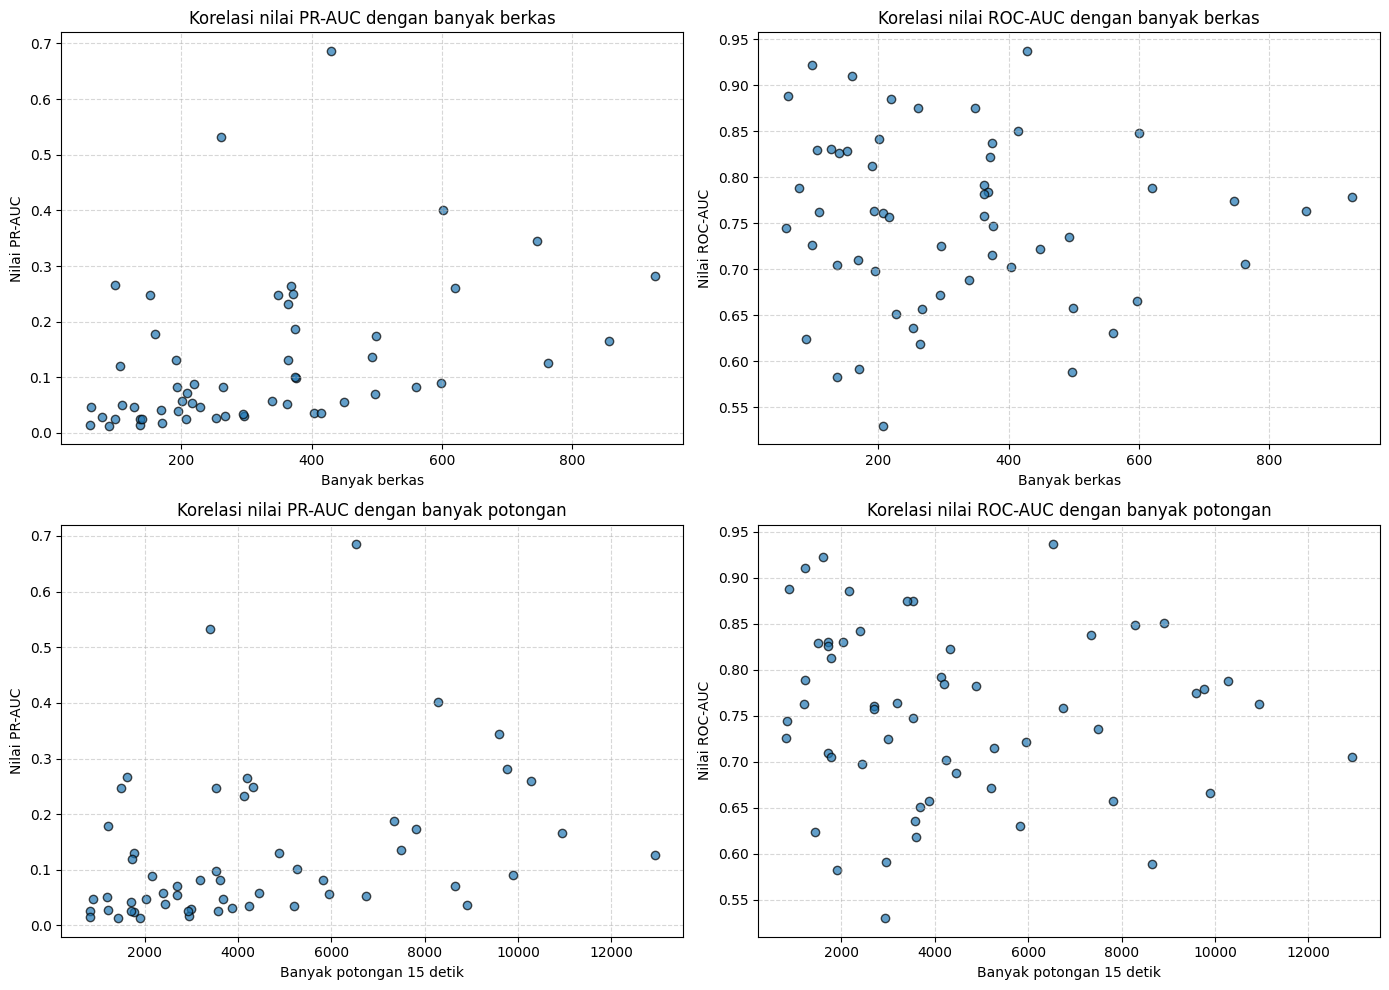

In [16]:
(
    cnn_result_df,
    cnn_merged,
    cnn_pr_auc_files_corr,
    cnn_roc_auc_files_corr,
    cnn_pr_auc_chunks_corr,
    cnn_roc_auc_chunks_corr,
) = calculate_correlations(
    "../prep/autotagging_moodtheme-train_clean.csv",
    "./mlflow_pgdump/f2_cnn_history.csv",
)
print(cnn_result_df)
plot_correlations(
    merged=cnn_merged,
    pr_auc_files_corr=cnn_pr_auc_files_corr,
    roc_auc_files_corr=cnn_roc_auc_files_corr,
    pr_auc_chunks_corr=cnn_pr_auc_files_corr,
    roc_auc_chunks_corr=cnn_roc_auc_chunks_corr,
)

In [17]:
print("CNN")
print(cnn_merged)

CNN
              files_count   dur_sum  chunks_count    pr_auc   roc_auc
label                                                                
action                296   45005.4          3000  0.030145  0.724872
adventure             264   54096.0          3606  0.082430  0.618517
advertising           363   61884.1          4125  0.232518  0.791479
background            404   63682.6          4245  0.034939  0.701714
ballad                193   47930.5          3195  0.082133  0.763326
calm                  267   58226.3          3881  0.030959  0.657037
children              152   22548.0          1503  0.247630  0.828462
christmas             368   62989.9          4199  0.264443  0.784140
commercial            191   26577.6          1771  0.130521  0.812463
cool                  170   44302.3          2953  0.017071  0.590985
corporate             349   53056.4          3537  0.247822  0.875019
dark                  620  154053.1         10270  0.260214  0.788029
deep            

   pr_auc_files_corr  roc_auc_files_corr  pr_auc_chunks_corr  \
0           0.418926           -0.073447            0.373591   

   roc_auc_chunks_corr  
0            -0.080447  


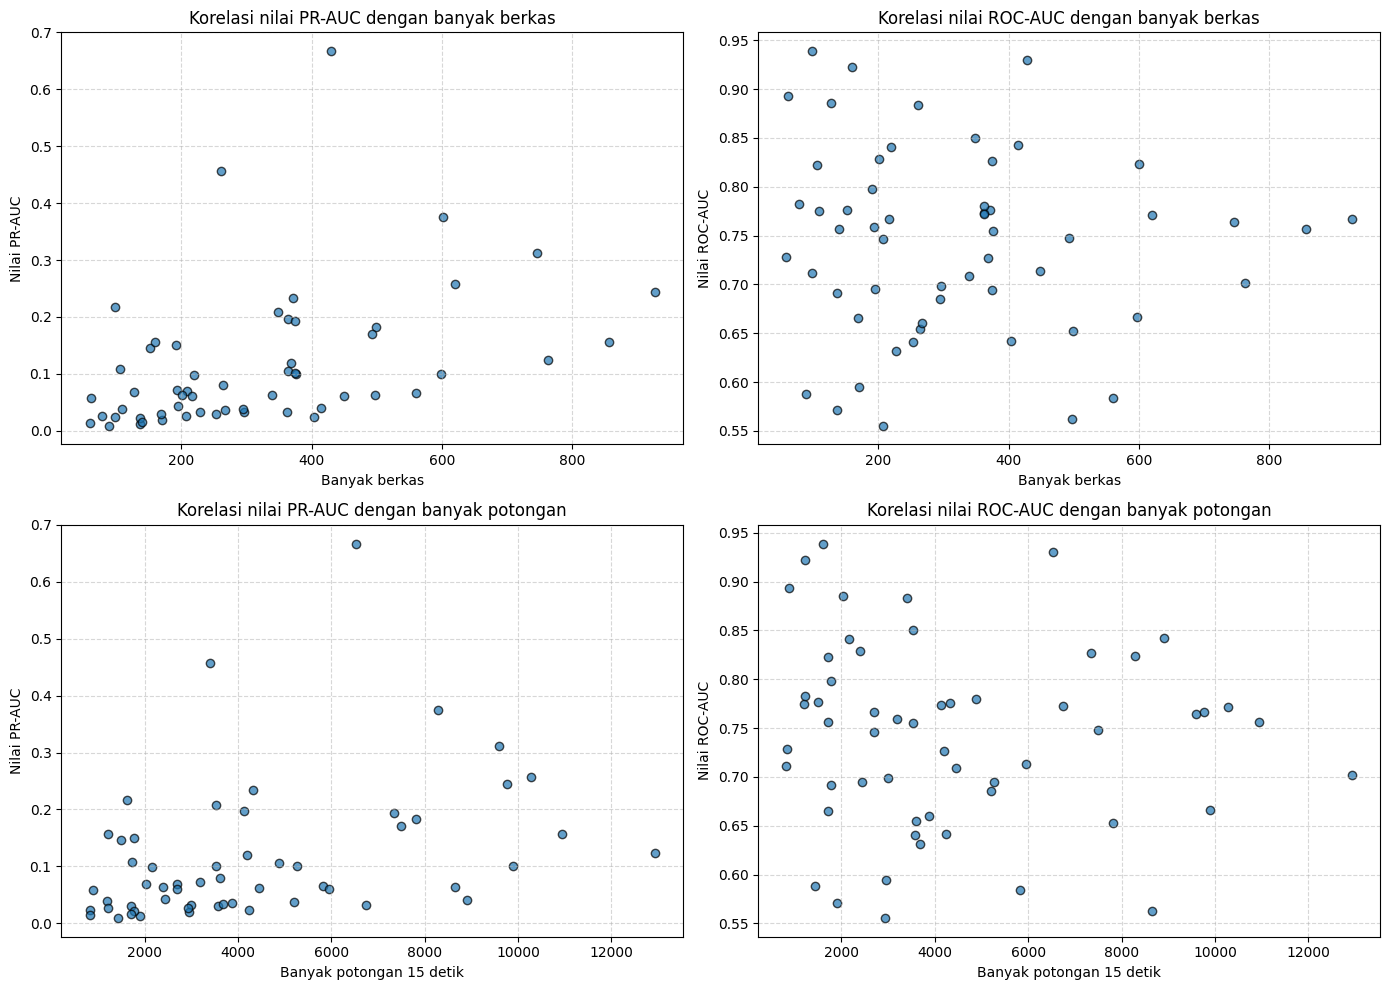

In [18]:
(
    gru_result_df,
    gru_merged,
    gru_pr_auc_files_corr,
    gru_roc_auc_files_corr,
    gru_pr_auc_chunks_corr,
    gru_roc_auc_chunks_corr,
) = calculate_correlations(
    "../prep/autotagging_moodtheme-train_clean.csv",
    "./mlflow_pgdump/f2_gru_history.csv",
)
print(gru_result_df)
plot_correlations(
    merged=gru_merged,
    pr_auc_files_corr=gru_pr_auc_files_corr,
    roc_auc_files_corr=gru_roc_auc_files_corr,
    pr_auc_chunks_corr=gru_pr_auc_files_corr,
    roc_auc_chunks_corr=gru_roc_auc_chunks_corr,
)

In [19]:
print("GRU")
print(gru_merged)

GRU
              files_count   dur_sum  chunks_count    pr_auc   roc_auc
label                                                                
action                296   45005.4          3000  0.032192  0.698417
adventure             264   54096.0          3606  0.079911  0.654425
advertising           363   61884.1          4125  0.196893  0.773255
background            404   63682.6          4245  0.023340  0.641996
ballad                193   47930.5          3195  0.072247  0.759097
calm                  267   58226.3          3881  0.036363  0.660403
children              152   22548.0          1503  0.146060  0.776480
christmas             368   62989.9          4199  0.119753  0.726553
commercial            191   26577.6          1771  0.150455  0.797766
cool                  170   44302.3          2953  0.019461  0.594590
corporate             349   53056.4          3537  0.207966  0.850115
dark                  620  154053.1         10270  0.257348  0.771432
deep            

   pr_auc_files_corr  roc_auc_files_corr  pr_auc_chunks_corr  \
0           0.401398           -0.056513             0.34339   

   roc_auc_chunks_corr  
0            -0.062965  


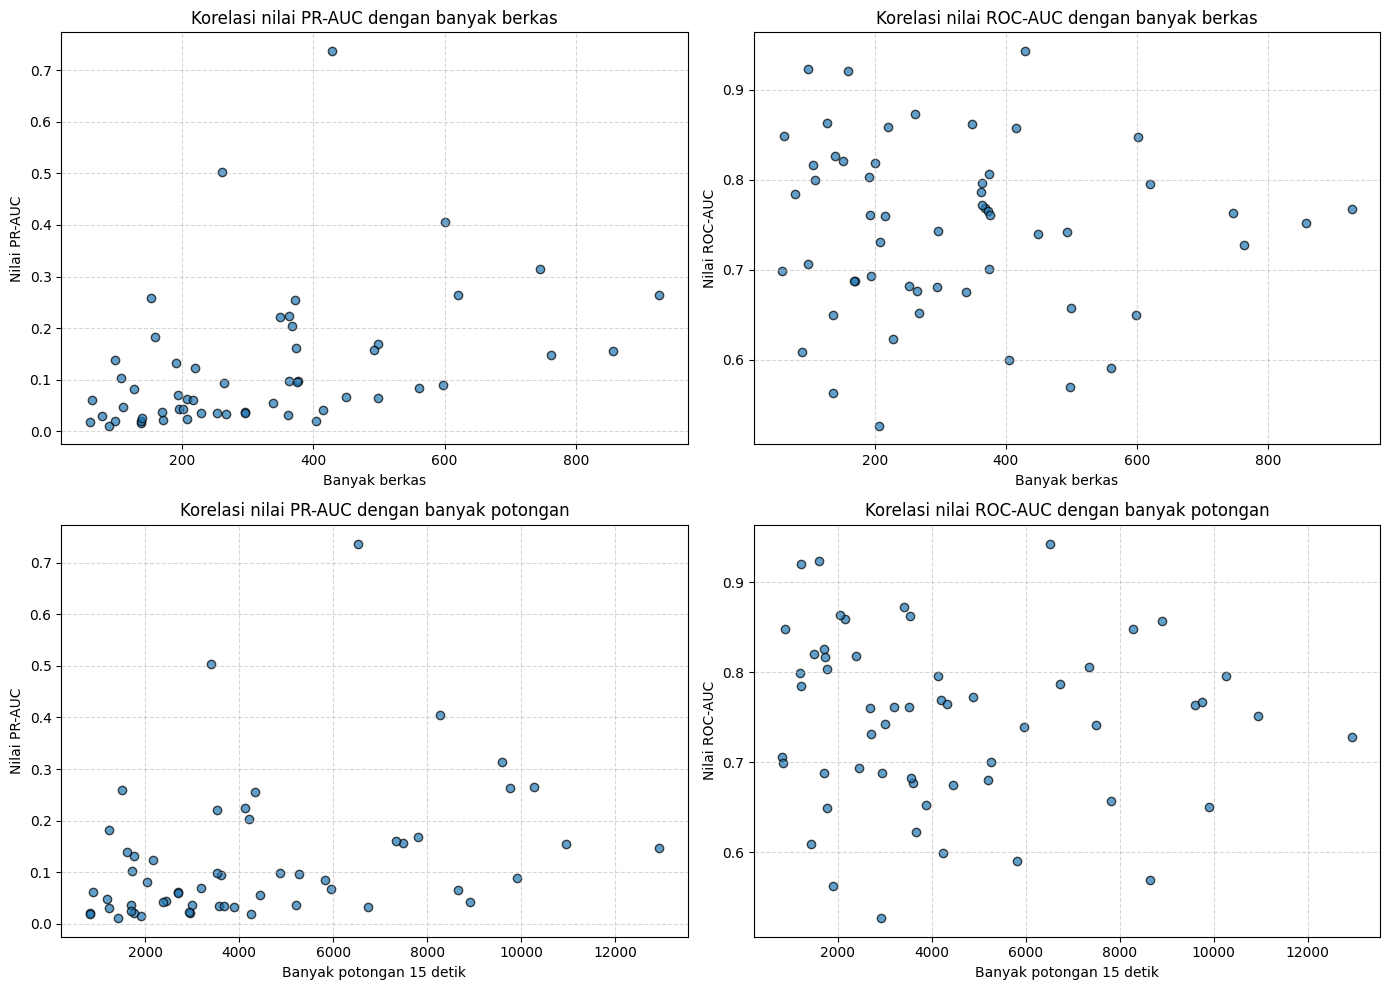

In [20]:
(
    attn_result_df,
    attn_merged,
    attn_pr_auc_files_corr,
    attn_roc_auc_files_corr,
    attn_pr_auc_chunks_corr,
    attn_roc_auc_chunks_corr,
) = calculate_correlations(
    "../prep/autotagging_moodtheme-train_clean.csv",
    "./mlflow_pgdump/f2_attn_history.csv",
)
print(attn_result_df)
plot_correlations(
    merged=attn_merged,
    pr_auc_files_corr=attn_pr_auc_files_corr,
    roc_auc_files_corr=attn_roc_auc_files_corr,
    pr_auc_chunks_corr=attn_pr_auc_files_corr,
    roc_auc_chunks_corr=attn_roc_auc_chunks_corr,
)

In [21]:
print("ATTN")
print(attn_merged)

ATTN
              files_count   dur_sum  chunks_count    pr_auc   roc_auc
label                                                                
action                296   45005.4          3000  0.037239  0.742968
adventure             264   54096.0          3606  0.094025  0.676802
advertising           363   61884.1          4125  0.223887  0.796248
background            404   63682.6          4245  0.019387  0.599764
ballad                193   47930.5          3195  0.069737  0.761014
calm                  267   58226.3          3881  0.032400  0.652349
children              152   22548.0          1503  0.258933  0.820442
christmas             368   62989.9          4199  0.203502  0.768969
commercial            191   26577.6          1771  0.132190  0.803069
cool                  170   44302.3          2953  0.021072  0.687925
corporate             349   53056.4          3537  0.220669  0.861945
dark                  620  154053.1         10270  0.264586  0.795656
deep           

# Normality, ANOVA, Kruskal-Wallis 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations


def extract_scores(csv_path):
    """Helper to extract PR-AUC and ROC-AUC series from a CSV."""
    df = pd.read_csv(csv_path)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    pr_mask = df["key"].str.startswith("test_pr_auc_")
    df_pr = df[pr_mask].copy()
    df_pr["label"] = df_pr["key"].apply(lambda x: x.split("---")[-1])
    pr_scores = df_pr.groupby("label")["value"].mean()

    roc_mask = df["key"].str.startswith("test_roc_auc_")
    df_roc = df[roc_mask].copy()
    df_roc["label"] = df_roc["key"].apply(lambda x: x.split("---")[-1])
    roc_scores = df_roc.groupby("label")["value"].mean()

    return pr_scores, roc_scores


def compare_model_distributions(cnn_csv, gru_csv, attn_csv):
    # 1. Extract data for all 3 models
    pr1, roc1 = extract_scores(cnn_csv)
    pr2, roc2 = extract_scores(gru_csv)
    pr3, roc3 = extract_scores(attn_csv)

    # Align data by label to ensure comparison for the exact same 56 labels
    # and drop any labels that might be missing in one of the files
    df_pr = pd.concat(
        [pr1, pr2, pr3], axis=1, keys=["CNN", "CNN_dengan_GRU", "CNN_dengan_Self-Attention"]
    ).dropna()
    df_roc = pd.concat(
        [roc1, roc2, roc3], axis=1, keys=["CNN", "CNN_dengan_GRU", "CNN_dengan_Self-Attention"]
    ).dropna()

    # 1. Plot distributions
    _, axs = plt.subplots(3, 2, figsize=(10, 12))
    # fig.suptitle("Distribution of PR-AUC and ROC-AUC scores per model")

    models = ["CNN", "CNN_dengan_GRU", "CNN_dengan_Self-Attention"]
    colors = ["skyblue", "salmon", "green"]

    for i, model in enumerate(models):
        # PR-AUC plots (left column)
        sns.histplot(df_pr[model], ax=axs[i, 0], color=colors[i], bins=20)  # type: ignore
        axs[i, 0].set_title(f"PR-AUC model {" ".join(model.split("_"))}")
        axs[i, 0].set_xlabel("Nilai")
        axs[i, 0].set_ylabel("Frekuensi")
        axs[i, 0].grid()

        # ROC-AUC plots (right column)
        sns.histplot(df_roc[model], ax=axs[i, 1], color=colors[i], bins=20)  # type: ignore
        axs[i, 1].set_title(f"ROC-AUC model {" ".join(model.split("_"))}")
        axs[i, 1].set_xlabel("Nilai")
        axs[i, 1].set_ylabel("Frekuensi")
        axs[i, 1].grid()

    plt.tight_layout()
    plt.show()

    # 2. Shapiro-Wilk normality test
    print("SHAPIRO-WILK NORMALITY TEST")
    print(
        "Null Hypothesis: The data is normally distributed (p > 0.05 implies normal).\n"
    )

    for model in models:
        stat_pr, p_pr = stats.shapiro(df_pr[model])
        stat_roc, p_roc = stats.shapiro(df_roc[model])
        print(
            f"{model} PR-AUC:  W={stat_pr:.4f}, p={p_pr:.4e} -> {'Normal' if p_pr > 0.05 else 'NOT Normal'}"
        )
        print(
            f"{model} ROC-AUC: W={stat_roc:.4f}, p={p_roc:.4e} -> {'Normal' if p_roc > 0.05 else 'NOT Normal'}"
        )

    # 3. One-Way ANOVA test
    print("\nONE-WAY ANOVA TEST")

    f_stat_pr, p_anova_pr = stats.f_oneway(
        df_pr["CNN"], df_pr["CNN_dengan_GRU"], df_pr["CNN_dengan_Self-Attention"]
    )
    f_stat_roc, p_anova_roc = stats.f_oneway(
        df_roc["CNN"], df_roc["CNN_dengan_GRU"], df_roc["CNN_dengan_Self-Attention"]
    )

    print(f"PR-AUC  -> F-statistic: {f_stat_pr:.4f}, p-value: {p_anova_pr:.4f}")
    print(f"ROC-AUC -> F-statistic: {f_stat_roc:.4f}, p-value: {p_anova_roc:.4f}")

    # 4. Kruskal-Wallis H-test
    print("\nKRUSKAL-WALLIS H-TEST")

    h_stat_pr, p_kruskal_pr = stats.kruskal(
        df_pr["CNN"], df_pr["CNN_dengan_GRU"], df_pr["CNN_dengan_Self-Attention"]
    )
    h_stat_roc, p_kruskal_roc = stats.kruskal(
        df_roc["CNN"], df_roc["CNN_dengan_GRU"], df_roc["CNN_dengan_Self-Attention"]
    )

    print(f"PR-AUC  -> H-statistic: {h_stat_pr:.4f}, p-value: {p_kruskal_pr:.4f}")
    print(f"ROC-AUC -> H-statistic: {h_stat_roc:.4f}, p-value: {p_kruskal_roc:.4f}")

    # 5. Friedman Chi-square test
    print("\nFRIEDMAN CHI-SQUARE TEST")

    c_stat_pr, p_friedman_pr = stats.friedmanchisquare(
        df_pr["CNN"], df_pr["CNN_dengan_GRU"], df_pr["CNN_dengan_Self-Attention"]
    )
    c_stat_roc, p_friedman_roc = stats.friedmanchisquare(
        df_roc["CNN"], df_roc["CNN_dengan_GRU"], df_roc["CNN_dengan_Self-Attention"]
    )

    print(f"PR-AUC  -> Chi-square: {c_stat_pr:.4f}, p-value: {p_friedman_pr:.4f}")
    print(f"ROC-AUC -> Chi-square: {c_stat_roc:.4f}, p-value: {p_friedman_roc:.4f}")

    # 6. Median scores
    print("\nMEDIAN PER-LABEL SCORES")
    print("PR-AUC medians:")
    print(df_pr.median().to_string())
    print("\nROC-AUC medians:")
    print(df_roc.median().to_string())

    # 7. Average (macro) scores
    print("\nAVERAGE (MACRO) PER-LABEL SCORES")
    print("PR-AUC macros:")
    print(df_pr.mean().to_string())
    print("\nROC-AUC macros:")
    print(df_roc.mean().to_string())

    # 8. Wilcoxson signed-rank test
    print("\nWILCOXON SIGNED-RANK TEST (PAIRWISE)")
    print("Note: Because you are doing 3 comparisons, you should ideally apply the")
    print("Bonferroni correction, making your threshold for significance p < 0.0167.\n")

    # itertools.combinations gets all unique pairs (e.g., A/B, A/C, B/C)
    pairs = list(combinations(models, 2))

    print("PR-AUC Pairwise")
    for m1, m2 in pairs:
        stat, p = stats.wilcoxon(df_pr[m1], df_pr[m2])
        print(f"{m1} vs {m2} -> W={stat:.1f}, p-value={p:.4f}")

    print("\nROC-AUC Pairwise")
    for m1, m2 in pairs:
        stat, p = stats.wilcoxon(df_roc[m1], df_roc[m2])
        print(f"{m1} vs {m2} -> W={stat:.1f}, p-value={p:.4f}")

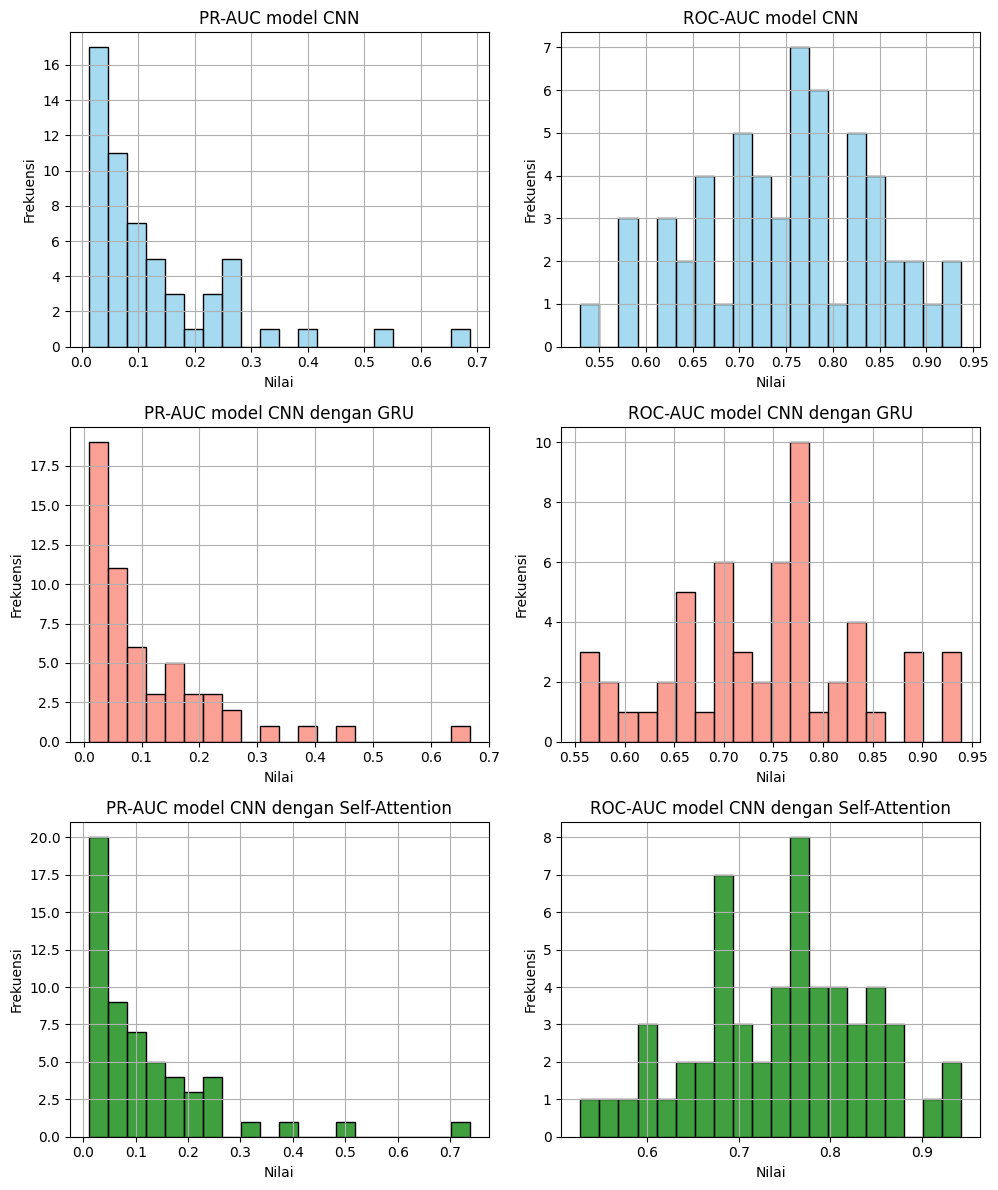

SHAPIRO-WILK NORMALITY TEST
Null Hypothesis: The data is normally distributed (p > 0.05 implies normal).

CNN PR-AUC:  W=0.7597, p=3.3514e-08 -> NOT Normal
CNN ROC-AUC: W=0.9888, p=8.8124e-01 -> Normal
CNN_dengan_GRU PR-AUC:  W=0.7521, p=2.3129e-08 -> NOT Normal
CNN_dengan_GRU ROC-AUC: W=0.9807, p=5.0599e-01 -> Normal
CNN_dengan_Self-Attention PR-AUC:  W=0.7330, p=9.2798e-09 -> NOT Normal
CNN_dengan_Self-Attention ROC-AUC: W=0.9882, p=8.5625e-01 -> Normal

ONE-WAY ANOVA TEST
PR-AUC  -> F-statistic: 0.1000, p-value: 0.9049
ROC-AUC -> F-statistic: 0.1553, p-value: 0.8563

KRUSKAL-WALLIS H-TEST
PR-AUC  -> H-statistic: 0.0876, p-value: 0.9571
ROC-AUC -> H-statistic: 0.3768, p-value: 0.8283

FRIEDMAN CHI-SQUARE TEST
PR-AUC  -> Chi-square: 3.4643, p-value: 0.1769
ROC-AUC -> Chi-square: 7.9643, p-value: 0.0186

MEDIAN PER-LABEL SCORES
PR-AUC medians:
CNN                          0.076679
CNN_dengan_GRU               0.069291
CNN_dengan_Self-Attention    0.075725

ROC-AUC medians:
CNN         

In [33]:
compare_model_distributions(
    './mlflow_pgdump/f2_cnn_history.csv',
    './mlflow_pgdump/f2_gru_history.csv',
    './mlflow_pgdump/f2_attn_history.csv'
    )

# All normality/Q-Q plots

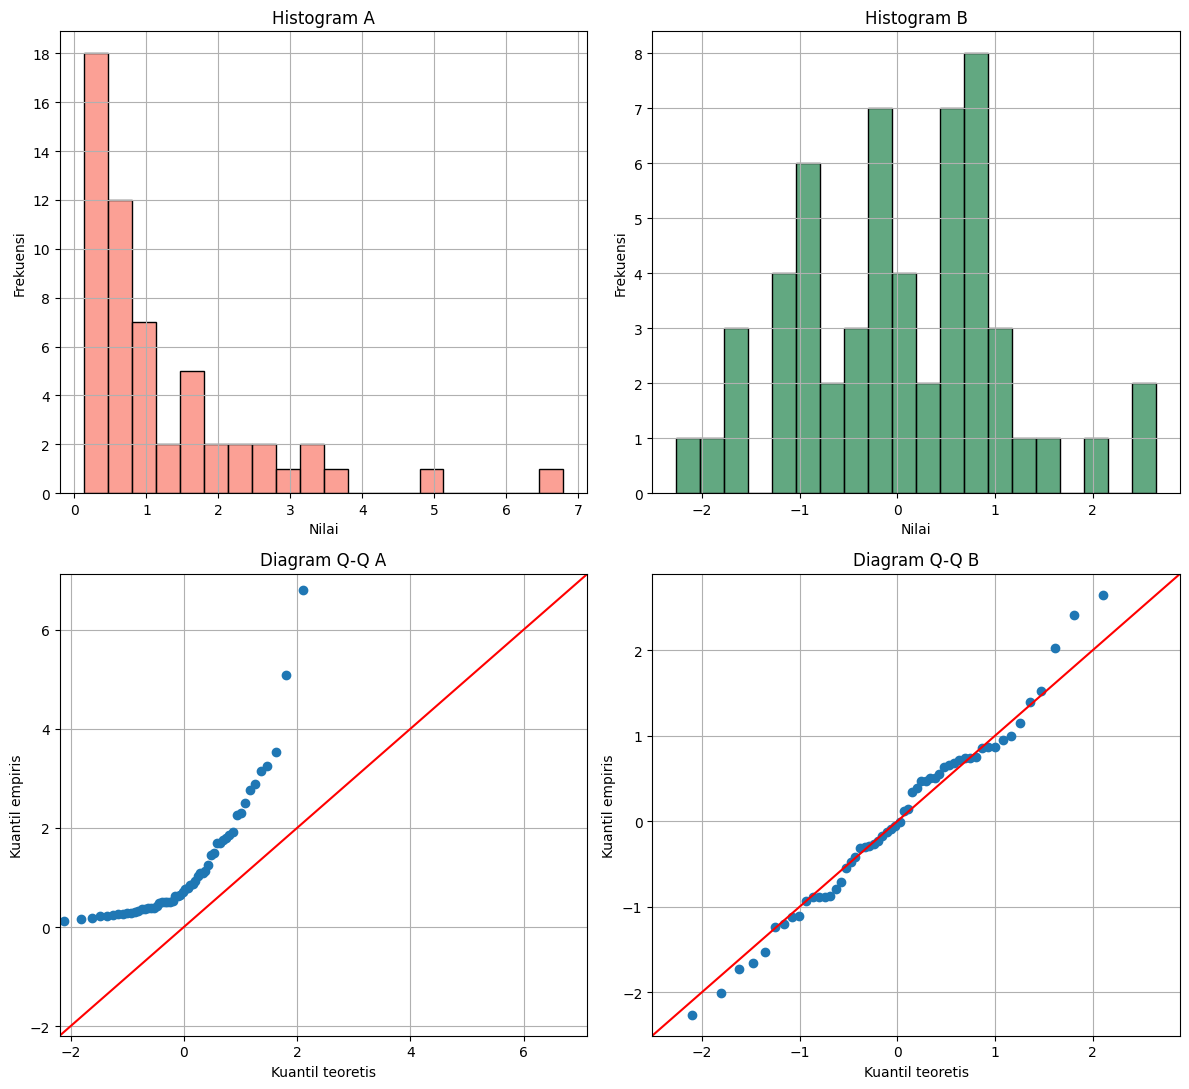

In [34]:
from numpy.random import MT19937
from numpy.random import RandomState, SeedSequence
import statsmodels.api as sm

# import scipy.stats as stats


def visualise_normality(some_csv):
    # This is just for visualisation sake in the final thesis paper
    pr1, _ = extract_scores(some_csv)

    rs = RandomState(MT19937(SeedSequence(37)))
    rands = rs.standard_normal(size=56)
    # rands = np.divide(rands, 10)

    _, axs = plt.subplots(2, 2, figsize=(12, 11))

    sns.histplot(pr1 * 10, ax=axs[0, 0], color="salmon", bins=20)
    axs[0, 0].set_title("Histogram A")
    axs[0, 0].set_xlabel("Nilai")
    axs[0, 0].set_ylabel("Frekuensi")
    axs[0, 0].grid()
    # axs[0, 0].set_xticks(np.arange(0.0, 0.8, 0.1))
    axs[0, 0].set_yticks(np.arange(0, 20, 2))

    # stats.probplot(pr1, plot=axs[1, 0])
    # axs[1, 0].set_title("")
    # axs[1, 0].set_xlabel("Kuantil teoretis")
    # axs[1, 0].set_ylabel("Kuantil empiris")
    # axs[1, 0].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 0].set_yticks(np.arange(-2, 3, 1))
    sm.qqplot(pr1 * 10, line="45", ax=axs[1, 0])
    axs[1, 0].set_xlabel("Kuantil teoretis")
    axs[1, 0].set_ylabel("Kuantil empiris")
    axs[1, 0].set_title("Diagram Q-Q A")
    axs[1, 0].grid()
    # axs[1, 0].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 0].set_yticks(np.arange(-2, 3, 1))

    # sns.histplot(roc1 * 10, ax=axs[0, 1], color="cornflowerblue", bins=20)
    # axs[0, 1].set_title("Contoh 2")
    # axs[0, 1].set_xlabel("Nilai")
    # axs[0, 1].set_ylabel("Frekuensi")
    # axs[0, 1].set_xticks(np.arange(0.4, 1.1, 0.1))

    # stats.probplot(roc1, dist="norm", plot=axs[1, 1], fit=False)
    # axs[1, 1].set_title("")
    # axs[1, 1].set_xlabel("Kuantil teoretis")
    # axs[1, 1].set_ylabel("Kuantil empiris")
    # axs[1, 1].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 1].set_yticks(np.arange(-2, 3, 1))
    # sm.qqplot(roc1 * 10, line="45", ax=axs[1, 1])
    # axs[1, 1].set_title("")
    # axs[1, 1].set_xlabel("Kuantil teoretis")
    # axs[1, 1].set_ylabel("Kuantil empiris")
    # axs[1, 1].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 1].set_yticks(np.arange(-2, 3, 1))

    sns.histplot(rands, ax=axs[0, 1], color="seagreen", bins=20)
    axs[0, 1].set_title("Histogram B")
    axs[0, 1].set_xlabel("Nilai")
    axs[0, 1].set_ylabel("Frekuensi")
    axs[0, 1].grid()
    axs[0, 1].set_xticks(np.arange(-2, 3, 1))

    # stats.probplot(rands, plot=axs[1, 1])
    # axs[1, 1].set_title("")
    # axs[1, 1].set_xlabel("Kuantil teoretis")
    # axs[1, 1].set_ylabel("Kuantil empiris")
    # axs[1, 1].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 1].set_yticks(np.arange(-2, 3, 1))
    sm.qqplot(rands, line="45", ax=axs[1, 1])
    axs[1, 1].set_xlabel("Kuantil teoretis")
    axs[1, 1].set_ylabel("Kuantil empiris")
    axs[1, 1].set_title("Diagram Q-Q B")
    axs[1, 1].grid()
    # axs[1, 1].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 1].set_yticks(np.arange(-2, 3, 1))

    plt.tight_layout()
    plt.show()


visualise_normality("./mlflow_pgdump/cnn_test_9f3cb9_history.csv")

In [25]:
import statsmodels.api as sm


def visualise_normality_all(cnn_csv, gru_csv, attn_csv):
    pr1, roc1 = extract_scores(cnn_csv)
    pr2, roc2 = extract_scores(gru_csv)
    pr3, roc3 = extract_scores(attn_csv)

    _, axs = plt.subplots(3, 2, figsize=(10, 12))

    sm.qqplot(pr1 * 10, line="45", ax=axs[0, 0])
    axs[0, 0].set_xlabel("Kuantil teoretis")
    axs[0, 0].set_ylabel("Kuantil empiris")
    axs[0, 0].set_title("PR-AUC model CNN")
    axs[0, 0].grid()

    sm.qqplot(roc1 * 10, line="45", ax=axs[0, 1])
    axs[0, 1].set_xlabel("Kuantil teoretis")
    axs[0, 1].set_ylabel("Kuantil empiris")
    axs[0, 1].set_title("ROC-AUC model CNN")
    axs[0, 1].grid()

    sm.qqplot(pr2 * 10, line="45", ax=axs[1, 0])
    axs[1, 0].set_xlabel("Kuantil teoretis")
    axs[1, 0].set_ylabel("Kuantil empiris")
    axs[1, 0].set_title("PR-AUC model CNN dengan GRU")
    axs[1, 0].grid()

    sm.qqplot(roc2 * 10, line="45", ax=axs[1, 1])
    axs[1, 1].set_xlabel("Kuantil teoretis")
    axs[1, 1].set_ylabel("Kuantil empiris")
    axs[1, 1].set_title("ROC-AUC model CNN dengan GRU")
    axs[1, 1].grid()

    sm.qqplot(pr3 * 10, line="45", ax=axs[2, 0])
    axs[2, 0].set_xlabel("Kuantil teoretis")
    axs[2, 0].set_ylabel("Kuantil empiris")
    axs[2, 0].set_title("PR-AUC model CNN dengan Self-Attention")
    axs[2, 0].grid()

    sm.qqplot(roc3 * 10, line="45", ax=axs[2, 1])
    axs[2, 1].set_xlabel("Kuantil teoretis")
    axs[2, 1].set_ylabel("Kuantil empiris")
    axs[2, 1].set_title("ROC-AUC model CNN dengan Self-Attention")
    axs[2, 1].grid()

    plt.tight_layout()
    plt.show()

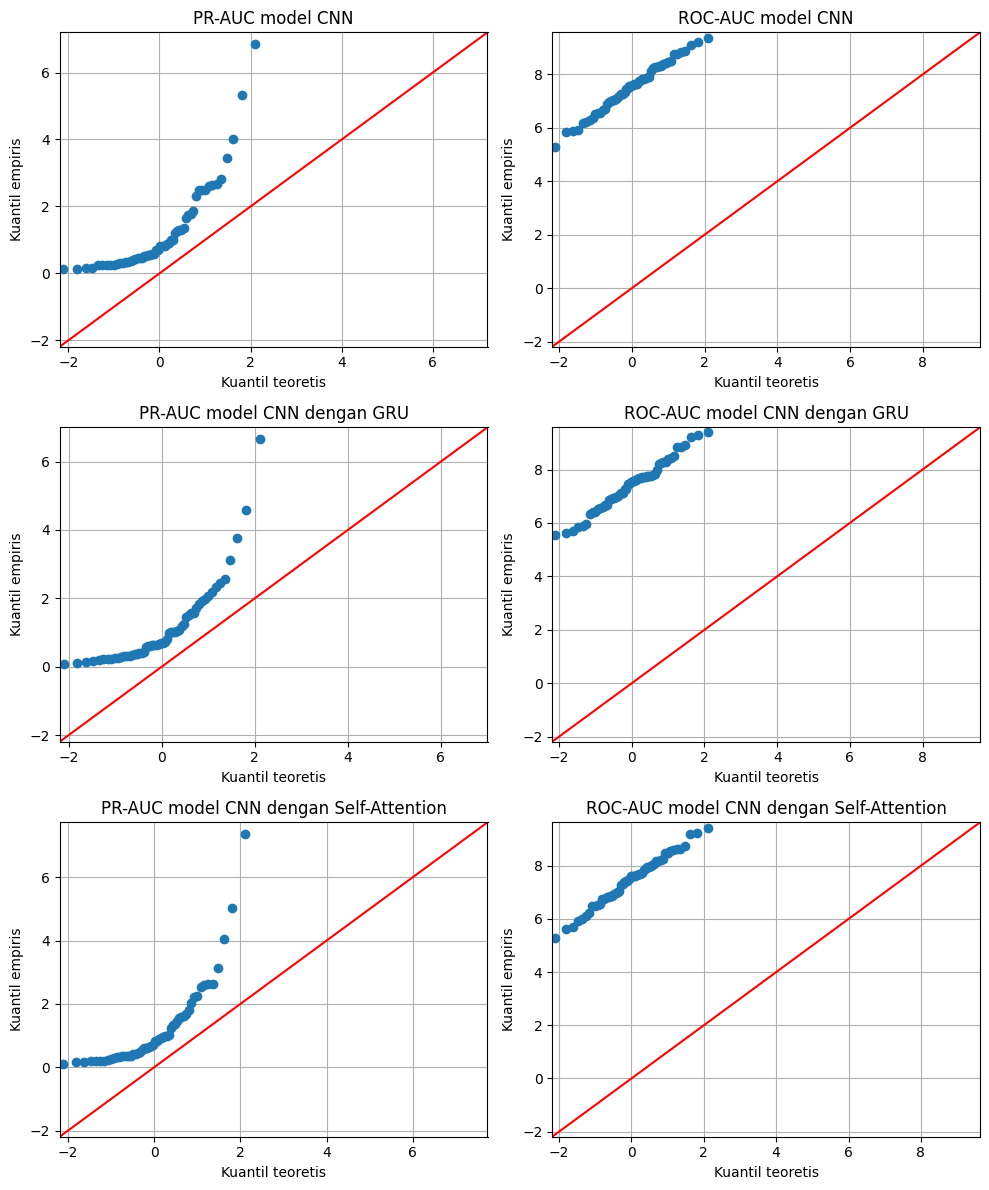

In [26]:
visualise_normality_all(
    './mlflow_pgdump/f2_cnn_history.csv',
    './mlflow_pgdump/f2_gru_history.csv',
    './mlflow_pgdump/f2_attn_history.csv'
    )

# All Corr plots

In [31]:
def plot_correlations_all(cnn_csv, gru_csv, attn_csv):
    files = [cnn_csv, gru_csv, attn_csv]
    models = ["CNN", "CNN dengan GRU", "CNN dengan Self-Attention"]

    _, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 12))

    for i, file in enumerate(files):
        (
            _,
            merged,
            _,
            _,
            pr_auc_chunks_corr,
            roc_auc_chunks_corr,
        ) = calculate_correlations(
            "../prep/autotagging_moodtheme-train_clean.csv", file
        )

        # Helper function to plot a single scatter + trendline
        def plot_scatter_with_trend(
            ax, x_data, y_data, xlabel, ylabel, title, corr_val
        ):
            # Plot the 56 dots
            ax.scatter(
                x_data,
                y_data,
                alpha=0.7,
                edgecolors="k",
                label=f"r = {corr_val:.4f}"
            )

            ax.set_title(title, fontsize=12)
            ax.set_xlabel(xlabel, fontsize=10)
            ax.set_ylabel(ylabel, fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.5)
            ax.legend()

        # PR-AUC vs Chunks
        plot_scatter_with_trend(
            ax=axs[i, 0],
            x_data=merged["chunks_count"],
            y_data=merged["pr_auc"],
            xlabel="Banyak potongan 15 detik",
            ylabel="Nilai PR-AUC",
            title=f"Korelasi pada {models[i]}",
            corr_val=pr_auc_chunks_corr,
        )

        # ROC-AUC vs Chunks
        plot_scatter_with_trend(
            ax=axs[i, 1],
            x_data=merged["chunks_count"],
            y_data=merged["roc_auc"],
            xlabel="Banyak potongan 15 detik",
            ylabel="Nilai ROC-AUC",
            title=f"Korelasi pada {models[i]}",
            corr_val=roc_auc_chunks_corr,
        )

    plt.tight_layout()
    plt.show()

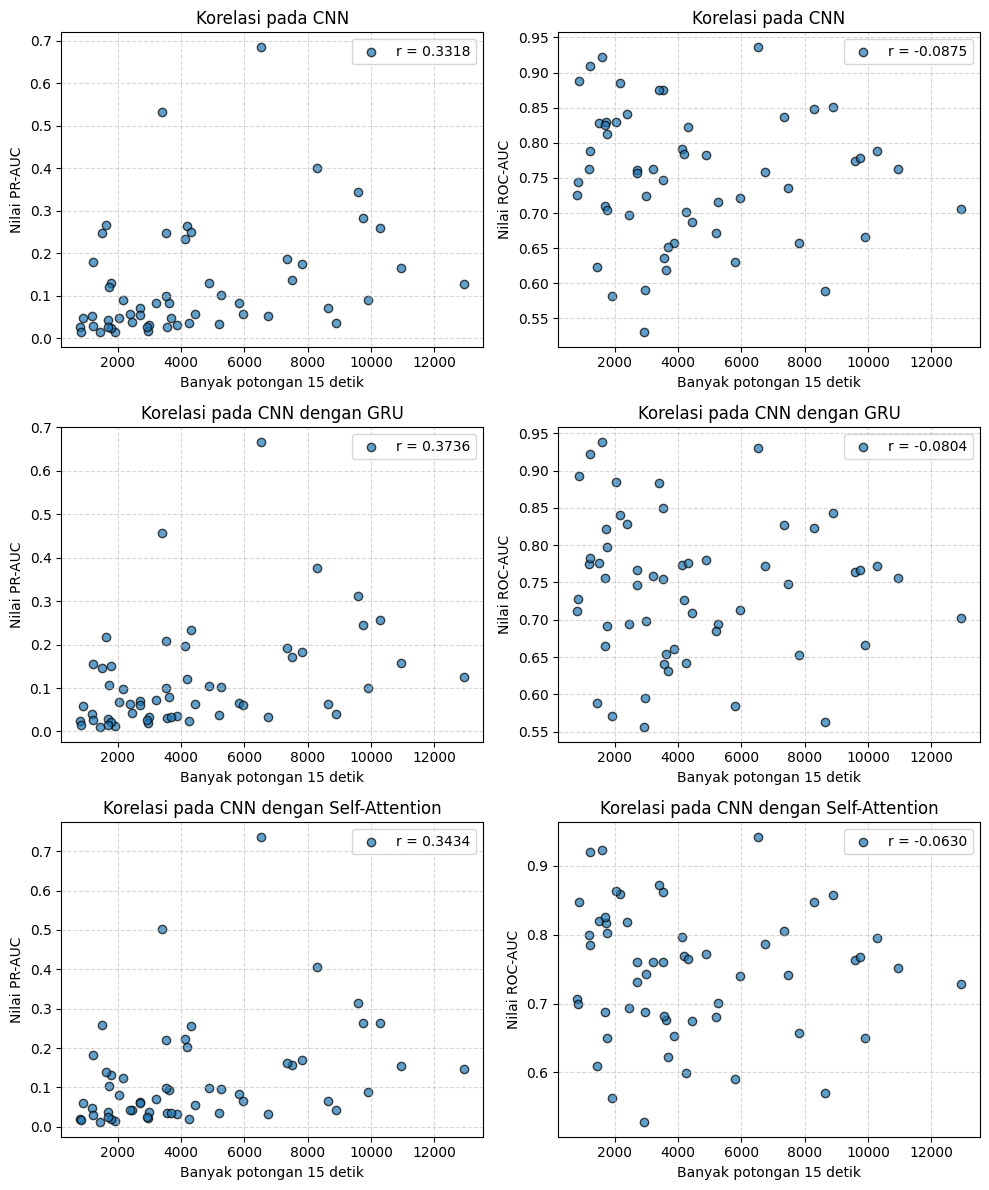

In [32]:
plot_correlations_all(
    './mlflow_pgdump/f2_cnn_history.csv',
    './mlflow_pgdump/f2_gru_history.csv',
    './mlflow_pgdump/f2_attn_history.csv'
    )

In [29]:
def plot_correlations_all_overlaid(cnn_csv, gru_csv, attn_csv):
    files = [cnn_csv, gru_csv, attn_csv]
    models = ["CNN", "CNN dengan GRU", "CNN dengan Self-Attention"]

    _, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

    for i, file in enumerate(files):
        (
            _,
            merged,
            _,
            _,
            pr_auc_chunks_corr,
            roc_auc_chunks_corr,
        ) = calculate_correlations(
            "../prep/autotagging_moodtheme-train_clean.csv", file
        )

        # Helper function to plot a single scatter + trendline
        def plot_scatter_with_trend(
            ax, x_data, y_data, xlabel, ylabel, title, corr_val
        ):
            # Plot the 56 dots
            ax.scatter(
                x_data,
                y_data,
                alpha=0.7,
                edgecolors="k",
                label=f"{models[i]}"
            )

            ax.set_title(title, fontsize=12)
            ax.set_xlabel(xlabel, fontsize=10)
            ax.set_ylabel(ylabel, fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.5)
            ax.legend()

        # PR-AUC vs Chunks
        plot_scatter_with_trend(
            ax=axs,
            x_data=merged["chunks_count"],
            y_data=merged["pr_auc"],
            xlabel="Banyak potongan 15 detik",
            ylabel="Nilai PR-AUC",
            # title=f"Korelasi pada ketiga variasi model",
            title="",
            corr_val=pr_auc_chunks_corr,
        )

    plt.tight_layout()
    plt.show()

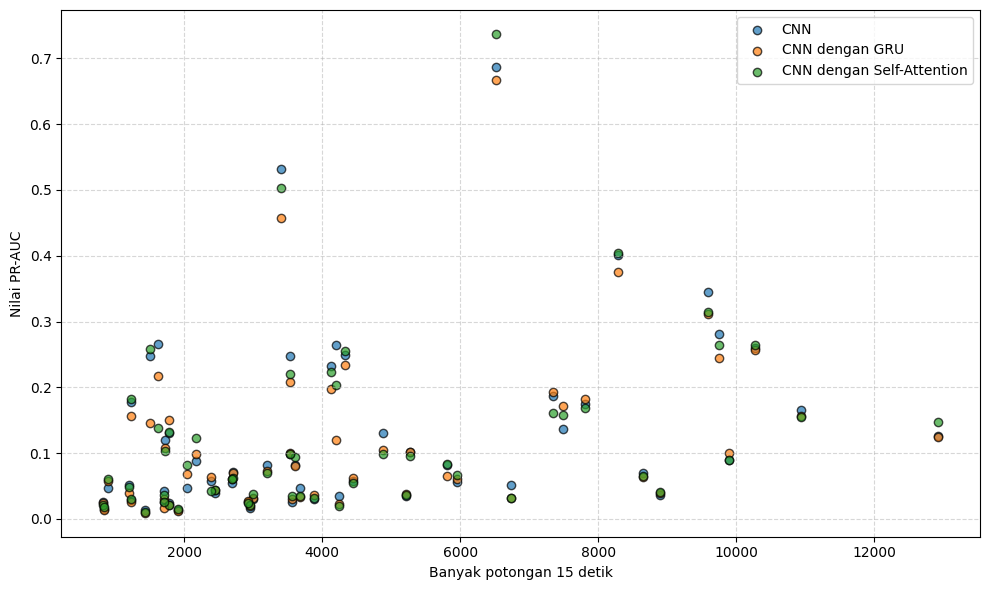

In [30]:
plot_correlations_all_overlaid(
    './mlflow_pgdump/f2_cnn_history.csv',
    './mlflow_pgdump/f2_gru_history.csv',
    './mlflow_pgdump/f2_attn_history.csv'
    )